In [1]:
import pandas as pd
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

In [2]:
# Mengimpor dataset
df = pd.read_csv('Data analysis.csv', sep=';')

# Menampilkan data awal
print("Data sebelum pre-processing:")
print(df.head())

Data sebelum pre-processing:
                                                text   label
0                                         it's okay.  Normal
1                 so what were you calling me about?  Normal
2  oh, i just wanted to see if you wanted to hang...  Normal
3                     sure, what did you want to do?  Normal
4          maybe we can go see a movie or something.  Normal


# PRE - PROCESSING

### Langkah 1 : Pembersihan teks

In [3]:
def clean_text(text):
    # Mengubah teks menjadi lowercase
    text = text.lower()
    # Menghapus tanda baca
    text = ''.join([char for char in text if char not in string.punctuation])
    # Menghapus angka
    text = re.sub(r'\d+', '', text)
    # Menghapus white space berlebihan
    text = text.strip()
    return text

# Terapkan pembersihan teks ke kolom 'text'
df['cleaned_text'] = df['text'].apply(clean_text)

### Langkah 2 : Menghapus stopwords

In [4]:
stop_words = set(stopwords.words('english'))  # Jika dataset berbahasa Indonesia, ganti dengan 'indonesian'

def remove_stopwords(text):
    # Tokenisasi dan hapus stopwords
    return ' '.join([word for word in text.split() if word not in stop_words])

# Terapkan penghapusan stopwords
df['cleaned_text'] = df['cleaned_text'].apply(remove_stopwords)

### Langkah 3 : Membagi data menjadi training dan testing set

In [5]:
X = df['cleaned_text']  # fitur teks
y = df['label']  # label

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Langkah 4 : Mengubah teks menjadi fitur numerik dengan TF-IDF

In [6]:
tfidf = TfidfVectorizer(max_features=5000)  # Menentukan jumlah fitur
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Menampilkan hasil pre-processing
print("\nData setelah pre-processing : \n")
print(df.head())


Data setelah pre-processing : 

                                                text   label  \
0                                         it's okay.  Normal   
1                 so what were you calling me about?  Normal   
2  oh, i just wanted to see if you wanted to hang...  Normal   
3                     sure, what did you want to do?  Normal   
4          maybe we can go see a movie or something.  Normal   

                         cleaned_text  
0                                okay  
1                             calling  
2  oh wanted see wanted hang tomorrow  
3                           sure want  
4        maybe go see movie something  


# EVALUASI MODEL

In [7]:
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model 1: Support Vector Machine (SVM)
svm_model = SVC()
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

# Model 2: Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

# Model 3: Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train_tfidf, y_train)
dt_pred = dt_model.predict(X_test_tfidf)

# Fungsi evaluasi model
def evaluate_model(y_true, y_pred, model_name):
    print(f"Evaluasi              : {model_name}")
    print(f"Akurasi               : {accuracy_score(y_true, y_pred)}")
    print(f"Classification Report :\n{classification_report(y_true, y_pred)}")
    print(f"Confusion Matrix :\n{confusion_matrix(y_true, y_pred)}")
    print("\n" + "="*50 + "\n")

# Evaluasi setiap model
evaluate_model(y_test, svm_pred, "Support Vector Machine")
evaluate_model(y_test, nb_pred,  "Naive Bayes")
evaluate_model(y_test, dt_pred,  "Decision Tree")


Evaluasi              : Support Vector Machine
Akurasi               : 0.7989690721649485
Classification Report :
              precision    recall  f1-score   support

     Anxiety       0.97      0.92      0.94        63
      Normal       0.74      0.91      0.81        55
      Stress       0.68      0.80      0.73        50
    Suicidal       1.00      0.27      0.42        26

    accuracy                           0.80       194
   macro avg       0.84      0.72      0.73       194
weighted avg       0.83      0.80      0.78       194

Confusion Matrix :
[[58  3  2  0]
 [ 1 50  4  0]
 [ 1  9 40  0]
 [ 0  6 13  7]]


Evaluasi              : Naive Bayes
Akurasi               : 0.7422680412371134
Classification Report :
              precision    recall  f1-score   support

     Anxiety       0.78      0.98      0.87        63
      Normal       0.91      0.71      0.80        55
      Stress       0.60      0.84      0.70        50
    Suicidal       1.00      0.04      0.07      

Evaluasi              : Support Vector Machine
Akurasi               : 0.7989690721649485
Classification Report :
              precision    recall  f1-score   support

     Anxiety       0.97      0.92      0.94        63
      Normal       0.74      0.91      0.81        55
      Stress       0.68      0.80      0.73        50
    Suicidal       1.00      0.27      0.42        26

    accuracy                           0.80       194
   macro avg       0.84      0.72      0.73       194
weighted avg       0.83      0.80      0.78       194



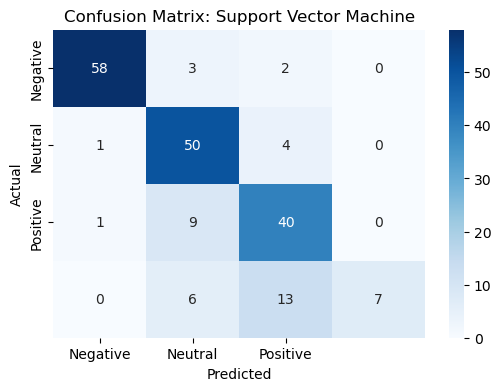



Evaluasi              : Naive Bayes
Akurasi               : 0.7422680412371134
Classification Report :
              precision    recall  f1-score   support

     Anxiety       0.78      0.98      0.87        63
      Normal       0.91      0.71      0.80        55
      Stress       0.60      0.84      0.70        50
    Suicidal       1.00      0.04      0.07        26

    accuracy                           0.74       194
   macro avg       0.82      0.64      0.61       194
weighted avg       0.80      0.74      0.70       194



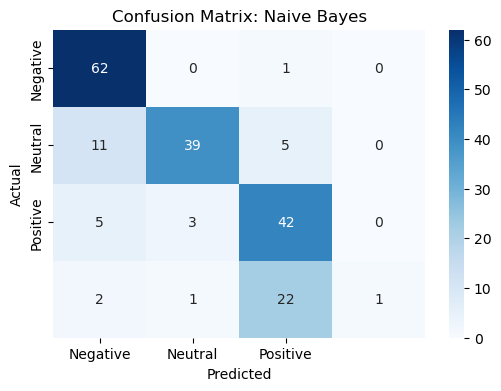



Evaluasi              : Decision Tree
Akurasi               : 0.7474226804123711
Classification Report :
              precision    recall  f1-score   support

     Anxiety       0.88      0.92      0.90        63
      Normal       0.68      0.91      0.78        55
      Stress       0.67      0.56      0.61        50
    Suicidal       0.69      0.35      0.46        26

    accuracy                           0.75       194
   macro avg       0.73      0.68      0.69       194
weighted avg       0.74      0.75      0.73       194



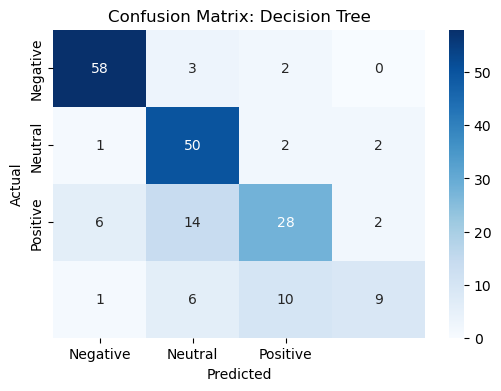

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fungsi untuk menampilkan confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Evaluasi dengan visualisasi
def evaluate_model_with_plot(y_true, y_pred, model_name):
    print(f"Evaluasi              : {model_name}")
    print(f"Akurasi               : {accuracy_score(y_true, y_pred)}")
    print(f"Classification Report :\n{classification_report(y_true, y_pred)}")
    plot_confusion_matrix(y_true, y_pred, model_name)
    print(f"\n")

# Evaluasi model dengan visualisasi confusion matrix
evaluate_model_with_plot(y_test, svm_pred, "Support Vector Machine")
evaluate_model_with_plot(y_test, nb_pred, "Naive Bayes")
evaluate_model_with_plot(y_test, dt_pred, "Decision Tree")


# CROSS VALIDATION

In [9]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Fungsi evaluasi cross-validation
def evaluate_model_cv(model, X, y, model_name, cv=5):
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    print(f"Cross-Validation   :{model_name}")
    print(f"Mean Accuracy      : {np.mean(scores):.4f}")
    print(f"Standard Deviation : {np.std(scores):.4f}")
    print(f"Scores             : {scores}")
    print("\n" + "="*50 + "\n")

# Cross-validation untuk setiap model
print("Cross-validation Scores : \n")
evaluate_model_cv(SVC(), X_train_tfidf, y_train, "Support Vector Machine")
evaluate_model_cv(MultinomialNB(), X_train_tfidf, y_train, "Naive Bayes")
evaluate_model_cv(DecisionTreeClassifier(), X_train_tfidf, y_train, "Decision Tree")

Cross-validation Scores : 

Cross-Validation   :Support Vector Machine
Mean Accuracy      : 0.8034
Standard Deviation : 0.0182
Scores             : [0.8        0.80645161 0.77419355 0.83116883 0.80519481]


Cross-Validation   :Naive Bayes
Mean Accuracy      : 0.7309
Standard Deviation : 0.0090
Scores             : [0.72258065 0.72903226 0.7483871  0.72727273 0.72727273]


Cross-Validation   :Decision Tree
Mean Accuracy      : 0.7879
Standard Deviation : 0.0301
Scores             : [0.72903226 0.8        0.80645161 0.81168831 0.79220779]




# TEKNIK SMOTE

In [10]:
from sklearn.pipeline import Pipeline
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE  # Pastikan library SMOTE diimpor

# Pipeline dengan SMOTE dan model
svm_pipeline = make_pipeline(SMOTE(random_state=42), SVC())
nb_pipeline = make_pipeline(SMOTE(random_state=42), MultinomialNB())
dt_pipeline = make_pipeline(SMOTE(random_state=42), DecisionTreeClassifier())

# Cross-validation dengan SMOTE
evaluate_model_cv(svm_pipeline, X_train_tfidf, y_train, "Support Vector Machine")
evaluate_model_cv(nb_pipeline, X_train_tfidf, y_train, "Naive Bayes")
evaluate_model_cv(dt_pipeline, X_train_tfidf, y_train, "Decision Tree")

Cross-Validation   :Support Vector Machine
Mean Accuracy      : 0.8073
Standard Deviation : 0.0140
Scores             : [0.80645161 0.80645161 0.78709677 0.83116883 0.80519481]


Cross-Validation   :Naive Bayes
Mean Accuracy      : 0.7349
Standard Deviation : 0.0367
Scores             : [0.71612903 0.67096774 0.76129032 0.76623377 0.75974026]


Cross-Validation   :Decision Tree
Mean Accuracy      : 0.7736
Standard Deviation : 0.0221
Scores             : [0.74193548 0.8        0.78709677 0.78571429 0.75324675]




# MODEL ENSEMBLE

In [11]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Definisi base models (gunakan model yang sudah Anda buat)
base_estimators = [
    ('svm', svm_model),            # Model SVM yang telah dilatih
    ('nb', nb_model),              # Model Naive Bayes yang telah dilatih
    ('dt', dt_model)               # Model Decision Tree yang telah dilatih
]

# Meta-model untuk Stacking
stack_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(),  # Meta-model
    cv=5  # Cross-validation pada stacking
)

# Latih Stacking Ensemble
stack_model.fit(X_train_tfidf, y_train)
stack_pred = stack_model.predict(X_test_tfidf)

# Evaluasi Model Stacking
evaluate_model(y_test, stack_pred, "Stacking Ensemble")


Evaluasi              : Stacking Ensemble
Akurasi               : 0.8556701030927835
Classification Report :
              precision    recall  f1-score   support

     Anxiety       0.95      0.97      0.96        63
      Normal       0.79      0.87      0.83        55
      Stress       0.83      0.80      0.82        50
    Suicidal       0.81      0.65      0.72        26

    accuracy                           0.86       194
   macro avg       0.85      0.82      0.83       194
weighted avg       0.86      0.86      0.85       194

Confusion Matrix :
[[61  1  1  0]
 [ 1 48  3  3]
 [ 2  7 40  1]
 [ 0  5  4 17]]




C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# PICKLE

In [12]:
import pickle

In [13]:
# Simpan model Stacking Ensemble ke file .pkl
with open('stacking_ensemble_model.pkl', 'wb') as file:
    pickle.dump(stack_model, file)

print("Model Stacking Ensemble berhasil disimpan!")

Model Stacking Ensemble berhasil disimpan!


In [14]:
# Muat kembali model dari file .pkl
with open('stacking_ensemble_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Gunakan model untuk membuat prediksi
predictions = loaded_model.predict(X_test_tfidf)
print("Prediksi menggunakan model yang dimuat kembali : \n\n", predictions)
print("\n")

# Evaluasi model
evaluate_model(y_test, predictions, "Loaded Stacking Ensemble")

Prediksi menggunakan model yang dimuat kembali : 

 ['Stress' 'Stress' 'Anxiety' 'Stress' 'Normal' 'Stress' 'Suicidal'
 'Anxiety' 'Normal' 'Anxiety' 'Normal' 'Anxiety' 'Stress' 'Anxiety'
 'Stress' 'Anxiety' 'Normal' 'Normal' 'Anxiety' 'Stress' 'Normal' 'Stress'
 'Normal' 'Anxiety' 'Suicidal' 'Stress' 'Stress' 'Stress' 'Suicidal'
 'Stress' 'Anxiety' 'Anxiety' 'Normal' 'Normal' 'Stress' 'Anxiety'
 'Anxiety' 'Anxiety' 'Normal' 'Anxiety' 'Normal' 'Anxiety' 'Normal'
 'Normal' 'Suicidal' 'Normal' 'Anxiety' 'Anxiety' 'Normal' 'Stress'
 'Normal' 'Stress' 'Stress' 'Normal' 'Anxiety' 'Normal' 'Stress' 'Anxiety'
 'Stress' 'Anxiety' 'Stress' 'Normal' 'Anxiety' 'Suicidal' 'Stress'
 'Suicidal' 'Anxiety' 'Stress' 'Normal' 'Anxiety' 'Stress' 'Anxiety'
 'Anxiety' 'Anxiety' 'Stress' 'Normal' 'Anxiety' 'Anxiety' 'Stress'
 'Anxiety' 'Anxiety' 'Normal' 'Normal' 'Normal' 'Suicidal' 'Normal'
 'Stress' 'Normal' 'Anxiety' 'Stress' 'Anxiety' 'Anxiety' 'Stress'
 'Anxiety' 'Anxiety' 'Normal' 'Stress' 'Normal' 'No